In [19]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'Warehouse'))

In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from Warehouse_Builder import Warehouse_Builder, WarehouseConfig, AisleConfig
from Inventory_Builder import Inventory_Builder, InventoryConfig
from Storage_Primitive import Singleton, Pallet
from Workload_Builder import BatchConfig, Batch, Task

## Warehouse & Inventory Setup

Build a 6-aisle warehouse, generate 120 SKUs, and run a greedy assignment to fill bins.
`Inventory_Manager` is currently a stub so assignment is done inline here.

In [ ]:
config = WarehouseConfig(
    total_aisles=24,
    aisle_splits=[1/24] * 24,
    aisle_configs=[
        AisleConfig(handling_type='conveyable',     storage_type='food',       unit_type='pallet',    bayXPerAisle=5, bayYPerAisle=6, storage_sizes=['medium']),
        AisleConfig(handling_type='conveyable',     storage_type='food',       unit_type='singleton', bayXPerAisle=5, bayYPerAisle=6, storage_sizes=['medium']),
        AisleConfig(handling_type='conveyable',     storage_type='clothing',   unit_type='pallet',    bayXPerAisle=5, bayYPerAisle=6, storage_sizes=['medium']),
        AisleConfig(handling_type='conveyable',     storage_type='clothing',   unit_type='singleton', bayXPerAisle=5, bayYPerAisle=6, storage_sizes=['medium']),
        AisleConfig(handling_type='conveyable',     storage_type='electronic', unit_type='pallet',    bayXPerAisle=5, bayYPerAisle=6, storage_sizes=['medium']),
        AisleConfig(handling_type='conveyable',     storage_type='electronic', unit_type='singleton', bayXPerAisle=5, bayYPerAisle=6, storage_sizes=['medium']),
        AisleConfig(handling_type='conveyable',     storage_type='furniture',  unit_type='pallet',    bayXPerAisle=5, bayYPerAisle=6, storage_sizes=['medium']),
        AisleConfig(handling_type='conveyable',     storage_type='furniture',  unit_type='singleton', bayXPerAisle=5, bayYPerAisle=6, storage_sizes=['medium']),
        AisleConfig(handling_type='conveyable',     storage_type='seasonal',   unit_type='pallet',    bayXPerAisle=5, bayYPerAisle=6, storage_sizes=['medium']),
        AisleConfig(handling_type='conveyable',     storage_type='seasonal',   unit_type='singleton', bayXPerAisle=5, bayYPerAisle=6, storage_sizes=['medium']),
        AisleConfig(handling_type='conveyable',     storage_type='chemical',   unit_type='pallet',    bayXPerAisle=5, bayYPerAisle=6, storage_sizes=['medium']),
        AisleConfig(handling_type='conveyable',     storage_type='chemical',   unit_type='singleton', bayXPerAisle=5, bayYPerAisle=6, storage_sizes=['medium']),
        AisleConfig(handling_type='non-conveyable', storage_type='food',       unit_type='pallet',    bayXPerAisle=4, bayYPerAisle=6, storage_sizes=['large']),
        AisleConfig(handling_type='non-conveyable', storage_type='food',       unit_type='singleton', bayXPerAisle=4, bayYPerAisle=6, storage_sizes=['large']),
        AisleConfig(handling_type='non-conveyable', storage_type='clothing',   unit_type='pallet',    bayXPerAisle=4, bayYPerAisle=6, storage_sizes=['large']),
        AisleConfig(handling_type='non-conveyable', storage_type='clothing',   unit_type='singleton', bayXPerAisle=4, bayYPerAisle=6, storage_sizes=['large']),
        AisleConfig(handling_type='non-conveyable', storage_type='electronic', unit_type='pallet',    bayXPerAisle=4, bayYPerAisle=6, storage_sizes=['large']),
        AisleConfig(handling_type='non-conveyable', storage_type='electronic', unit_type='singleton', bayXPerAisle=4, bayYPerAisle=6, storage_sizes=['large']),
        AisleConfig(handling_type='non-conveyable', storage_type='furniture',  unit_type='pallet',    bayXPerAisle=4, bayYPerAisle=6, storage_sizes=['large']),
        AisleConfig(handling_type='non-conveyable', storage_type='furniture',  unit_type='singleton', bayXPerAisle=4, bayYPerAisle=6, storage_sizes=['large']),
        AisleConfig(handling_type='non-conveyable', storage_type='seasonal',   unit_type='pallet',    bayXPerAisle=4, bayYPerAisle=6, storage_sizes=['large']),
        AisleConfig(handling_type='non-conveyable', storage_type='seasonal',   unit_type='singleton', bayXPerAisle=4, bayYPerAisle=6, storage_sizes=['large']),
        AisleConfig(handling_type='non-conveyable', storage_type='chemical',   unit_type='pallet',    bayXPerAisle=4, bayYPerAisle=6, storage_sizes=['large']),
        AisleConfig(handling_type='non-conveyable', storage_type='chemical',   unit_type='singleton', bayXPerAisle=4, bayYPerAisle=6, storage_sizes=['large']),
    ]
)
warehouse = Warehouse_Builder().from_config(config).build()
print(f'Aisles     : {len(warehouse.aisles)}')
print(f'Total bins : {len(warehouse.bins)}')

In [22]:
inv_config = InventoryConfig(
    num_skus=120,
    handling_splits=[0.5, 0.5],
    category_splits=[1/6] * 6,
)
inventory = Inventory_Builder().from_config(inv_config).build()
print(f'SKUs generated : {len(inventory.cartons)}')

SKUs generated : 120


In [ ]:
_PALLET_SIZES = {'large', 'extra_large'}
pool = list(inventory.cartons)

for bin_ in warehouse.bins:
    unit_class = Pallet if bin_.unit_type == 'pallet' else Singleton
    candidates = [c for c in pool if c.storage_type == bin_.storage_handling_type]
    for carton in candidates:
        try:
            bin_.storage = unit_class(carton, 1)
            pool.remove(carton)
            break
        except ValueError:
            continue

assigned = sum(1 for b in warehouse.bins if b.storage is not None)
print(f'Assigned           : {assigned} / {len(warehouse.bins)} bins  ({assigned / len(warehouse.bins):.0%})')
print(f'Unassigned cartons : {len(pool)}')

## Batch Generation

A `BatchConfig` parameterises the pick-size distribution.  
Each `Batch` draws `num_skus ~ N(0.20·n, 0.05·n)` and a uniform threshold; items whose
`demand.frequency` exceeds the threshold are the eligible pool, from which `num_skus` are sampled.

In [ ]:
random.seed(42)
affinity  = inventory.affinity_matrix()
batch_cfg = BatchConfig(inventory_size=len(inventory.cartons))
batch     = Batch(batch_cfg, inventory, affinity=affinity)

print(f'Pick threshold : {batch.threshold:.3f}  (items with frequency > this qualify)')
print(f'Target SKUs    : {batch.num_skus}')
print(f'Picks in batch : {len(batch.items)}')

## Task Generation

`Task.from_batch` splits the batch by aisle, then plans a sequential path through each aisle's
pick bins: bins are grouped by `bayX` column, and each column is traversed in the Y direction
that minimises the entry-distance from the previous position.

In [25]:
tasks = Task.from_batch(batch, warehouse)

def _path_dist(t):
    return sum(
        abs(t.path[i].bayX - t.path[i+1].bayX) + abs(t.path[i].bayY - t.path[i+1].bayY)
        for i in range(len(t.path) - 1)
    )

rows = [
    {
        'aisle_id'             : t.aisle_id,
        'handling_type'        : next(a.handling_type for a in warehouse.aisles if a.aisle_id == t.aisle_id),
        'storage_type'         : next(a.storage_type for a in warehouse.aisles if a.aisle_id == t.aisle_id),
        'storage_handling_type': next(a.storage_handling_type for a in warehouse.aisles if a.aisle_id == t.aisle_id),
        'picks'                : len(t.items),
        'stops'                : len(t.path),
        'path_dist'            : _path_dist(t),
    }
    for t in tasks
]
pd.DataFrame(rows).sort_values('aisle_id').reset_index(drop=True)

,aisle_id,handling_type,storage_type,storage_handling_type,picks,stops,path_dist
0,31,non-conveyable,food,"(non-conveyable, food)",1,1,0
1,32,non-conveyable,clothing,"(non-conveyable, clothing)",1,1,0
2,34,non-conveyable,furniture,"(non-conveyable, furniture)",6,6,7
3,35,non-conveyable,seasonal,"(non-conveyable, seasonal)",3,3,5
4,36,non-conveyable,chemical,"(non-conveyable, chemical)",3,3,2


## Path Visualisation

Each plot shows one aisle's bin grid.  
- **Orange** bins are pick targets (SKU and quantity labelled).  
- **Blue** bins are stocked but not in this batch.  
- **Grey** bins are empty.  
- Red arrows show the planned traversal order; corner numbers are stop indices.

In [26]:
from Picking_Visualization import plot_task

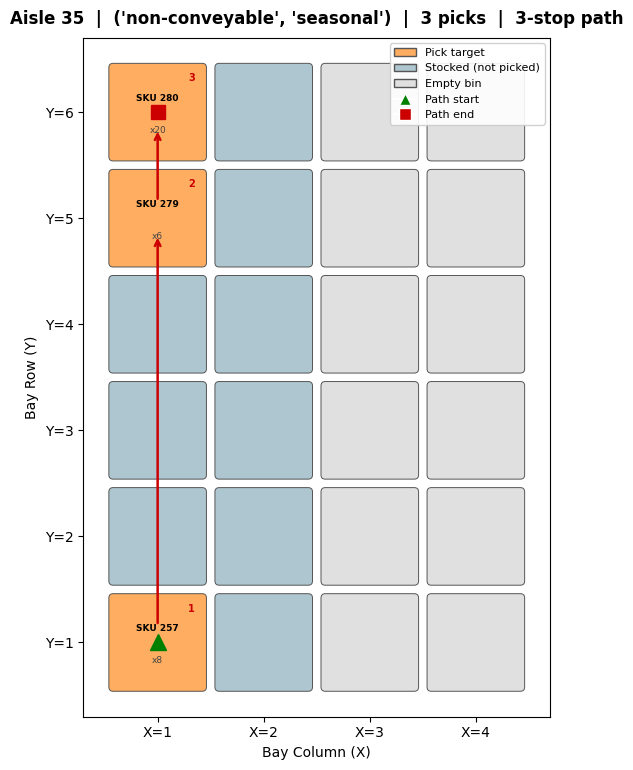

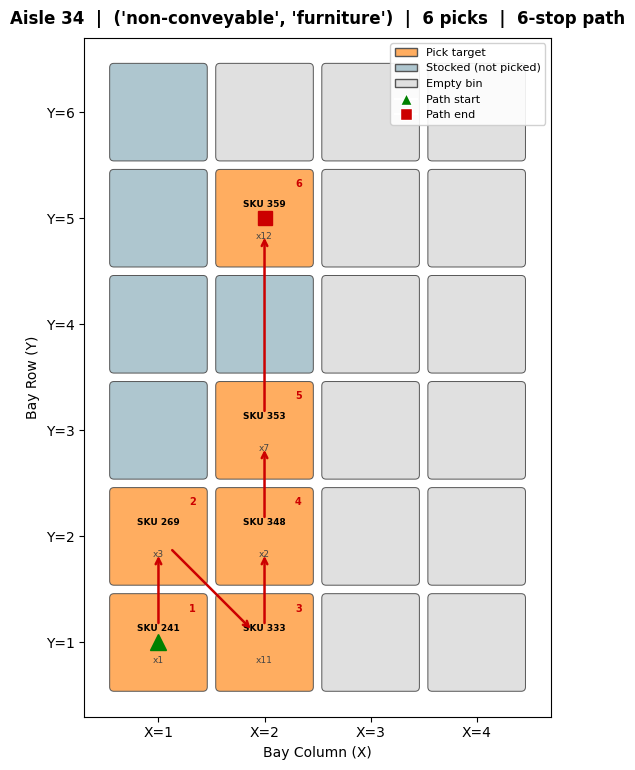

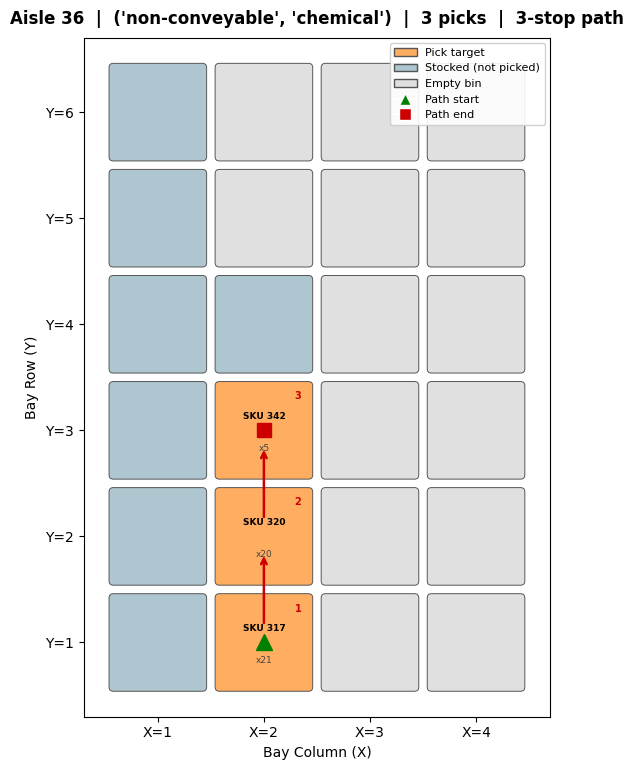

In [27]:
show = tasks[:3]
if not show:
    print('No tasks generated — try re-running with a different seed or lower threshold.')
else:
    for task in show:
        plot_task(task)